# Lab 01 — Example Solution

**Posted after lab as a reference.** Compare it against your own notebook to check your approach — but the work you submit must be your own. If something here is unfamiliar, revisit the Prelab 01 Walkthrough notebook, which explains each step in detail.


In [ ]:
# PART I - Scatter Plot and Histogram
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats 

# Text formatting defaults
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 10

#Loading the data files
df = pd.read_csv('../Data/time_voltage_data.csv')
time = df['Time'].values
voltage = df['Volts'].values

In [ ]:
# Compute Statistics
v_mean = np.mean(voltage)
v_median = np.median(voltage)
v_std = np.std(voltage, ddof=1)
v_var = np.var(voltage, ddof=1)

# Print the results
print(f"Mean Voltage: {v_mean:.4f} V")
print(f"Median Voltage: {v_median:.4f} V")
print(f"Standard Deviation: {v_std:.4f} V")
print(f"Variance: {v_var:.4f} V^2")

Mean Voltage: 5.2350 V
Median Voltage: 5.3176 V
Standard Deviation: 2.2113 V
Variance: 4.8898 V


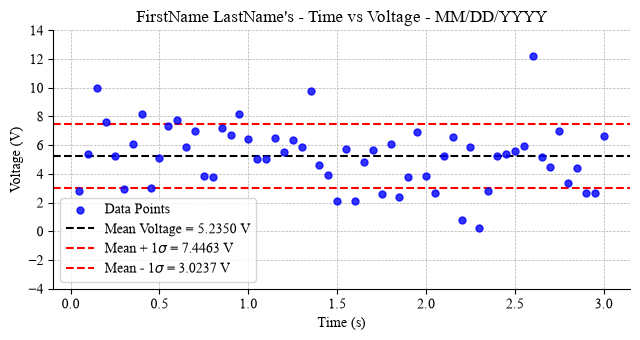

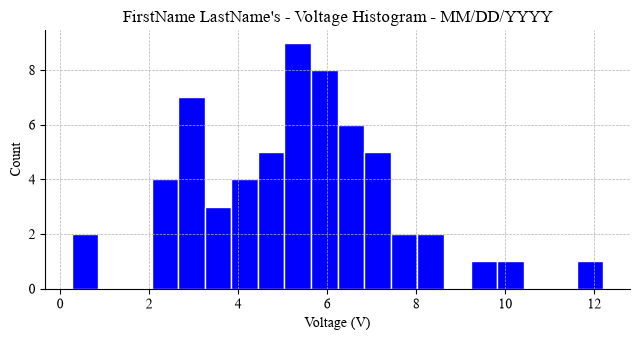

In [8]:
# Creating a scatter plot of Voltage vs Time
fig1, ax1 = plt.subplots(figsize=(6.5, 3.5))
fig1.patch.set_facecolor('white')

ax1.scatter(time, voltage, color='blue', s=25, alpha=0.8, zorder=3, label='Data Points')
ax1.axhline(v_mean, color='black', linewidth=1.5,  linestyle='--',
 label=f'Mean Voltage = {v_mean:.4f} V')
ax1.axhline(v_mean + v_std, color='red', linewidth=1.5, linestyle='--',
 label=f'Mean + 1$\\sigma$ = {v_mean + v_std:.4f} V')
ax1.axhline(v_mean - v_std, color='red', linewidth=1.5, linestyle='--',
 label=f'Mean - 1$\\sigma$ = {v_mean - v_std:.4f} V')

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title("FirstName LastName's - Time vs Voltage - MM/DD/YYYY")
ax1.legend(loc='lower left')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.set_ylim(-4, 14)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.tight_layout()

# Creating a histogram of Voltage
fig2, ax2 = plt.subplots(figsize=(6.5, 3.5))
fig2.patch.set_facecolor('white')
ax2.hist(voltage, bins=20, color='blue', edgecolor='white')
ax2.set_xlabel('Voltage (V)')
ax2.set_ylabel('Count')
ax2.set_title("FirstName LastName's - Voltage Histogram - MM/DD/YYYY")
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()

# Saving the figures
fig1.savefig('../Figures/FirstName_LastName_Lab01_Scatter.png', dpi=600, bbox_inches='tight')
fig1.savefig('../Figures/FirstName_LastName_Lab01_Scatter.pdf', dpi=600, bbox_inches='tight')

fig2.savefig('../Figures/FirstName_LastName_Lab01_Histogram.png', dpi=600, bbox_inches='tight')
fig2.savefig('../Figures/FirstName_LastName_Lab01_Histogram.pdf', dpi=600, bbox_inches='tight')


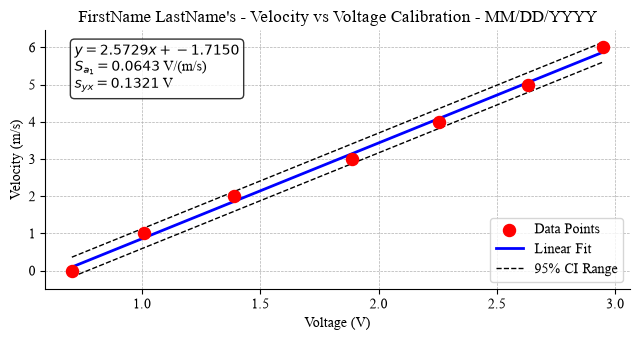

In [9]:
#PART II - Linear Curve Fit on Scatter Plot

# Enter velocity and voltage data as numpy arrays
velocity = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0,6.0])
voltage = np.array([0.7036, 1.0096, 1.3907, 1.8867, 2.2557, 2.6313, 2.9504])

# Fit a linear regression model to the data
coeffs = np.polyfit(voltage, velocity, 1)   # returns [slope, intercept]
velocity_fit = np.polyval(coeffs, voltage)  # predicted velocity values from the fit

#Compute standard error and confidence intervals
N = len(voltage) #number of data points
nu = N - 2 # degrees of freedom: a linear fit estimates 2 parameters, so nu = N - 2
residuals = velocity - velocity_fit
s_yx = np.sqrt(np.sum(residuals**2) / nu) # standard error of the fit (units of y: m/s)

# t-value for a two-sided 95% CI. Careful! ppf() takes the CUMULATIVE probability,
# so for 95% confidence use q = 1 - 0.05/2 = 0.975 (this matches the t-table value,
# e.g. 2.571 for nu = 5). Using 0.95 here is a common mistake: it gives only a 90% CI.
t_val = stats.t.ppf(0.975, df=nu)
CI = t_val * s_yx #Half-width of the confidence interval
S_a1 = s_yx / np.sqrt(np.sum((voltage - np.mean(voltage))**2)) # standard error of the slope (units of slope: (m/s)/V)

# Create a scatter plot of Voltage vs Velocity with the linear fit
v_range = np.linspace(min(voltage), max(voltage), 200)
fit_line = np.polyval(coeffs, v_range)

fig3, ax3 = plt.subplots(figsize=(6.5, 3.5))
fig3.patch.set_facecolor('white')
ax3.scatter(voltage, velocity, color='red', s=75, zorder=5, label='Data Points')
ax3.plot(v_range, fit_line, color='blue', linewidth=2, label='Linear Fit')
ax3.plot(v_range, fit_line + CI, color='black', linewidth=1, linestyle='--', label='95% CI Range')
ax3.plot(v_range, fit_line - CI, color='black', linewidth=1, linestyle='--')

fit_label = (f'$ y = {coeffs[0]:.4f}x + {coeffs[1]:.4f} $\n'
             f'$S_{{a_1}} = {S_a1:.4f}$ (m/s)/V\n'
             f'$s_{{yx}} = {s_yx:.4f}$ m/s')
ax3.text(0.05, 0.95, fit_label, transform=ax3.transAxes, fontsize=10,
          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3.set_xlabel('Voltage (V)')
ax3.set_ylabel('Velocity (m/s)')
ax3.set_title("FirstName LastName's - Velocity vs Voltage Calibration - MM/DD/YYYY")
ax3.legend(loc='lower right')
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()

# Saving the figure
fig3.savefig('../Figures/FirstName_LastName_Lab01_CurveFit.png', dpi=600, bbox_inches='tight')
fig3.savefig('../Figures/FirstName_LastName_Lab01_CurveFit.pdf', dpi=600, bbox_inches='tight')



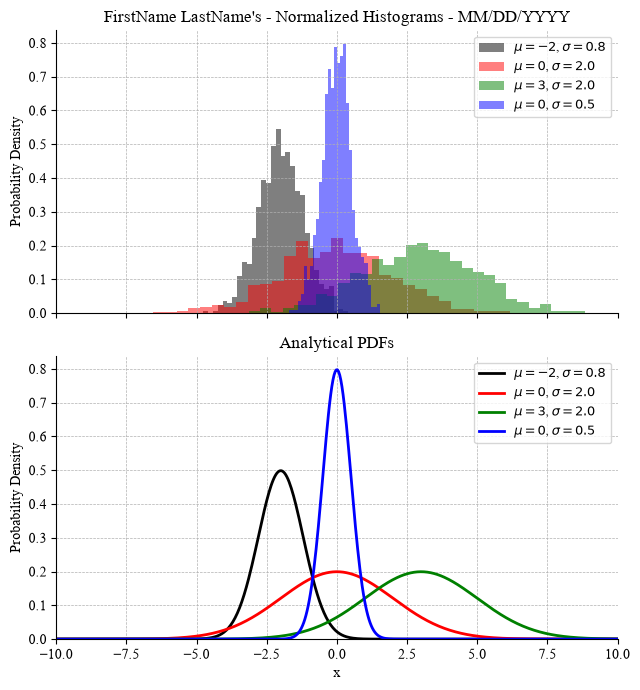

In [10]:
# PART III - Synthetic Data: Histograms and Probability Density Functions

N = 1000  # Number of samples
# NOTE: use a list [...] here, not a set {...} - sets have no guaranteed order,
# so colors and labels would not reliably match the distributions!
params = [(-2, 0.80), (0, 0.50), (0, 2.00), (3, 2.00)]  # (mean, std_dev) for each distribution
colors = ['black', 'red', 'green', 'blue']  # Colors for each distribution

# List comprehension: generates one dataset per (mu, sigma) pair
datasets = [np.random.randn(N) * sigma + mu for mu, sigma in params]

#Define the PDF function
def normal_pdf(x, mu, sigma):
    #Evaluate the normal PDF at x
    y = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return y

x = np.linspace(-10, 10, num= 500) # x values for PDF evaluation
fig4, (ax4_top, ax4_bot) = plt.subplots(2,1,figsize=(6.5, 7.0), sharex=True)
fig4.patch.set_facecolor('white')

for(mu,sigma), data, color in zip(params, datasets, colors):
    # Plot histogram
    label = rf'$\mu={mu}$, $\sigma={sigma}$'
    # Top panel, normalized histogram
    ax4_top.hist(data, bins=20, density=True, color=color, alpha=0.5, label=label)
    # Bottom panel: Analytical PDF
    ax4_bot.plot(x, normal_pdf(x, mu, sigma), color=color, linewidth=2, label=label)
   
ax4_top.set_ylabel('Probability Density')
ax4_top.set_title("FirstName LastName's - Normalized Histograms - MM/DD/YYYY")
ax4_top.legend(fontsize=9)
ax4_top.grid(True, linestyle='--', linewidth=0.5)
ax4_top.spines['top'].set_visible(False)
ax4_top.spines['right'].set_visible(False)
ax4_top.set_ylim(bottom=0)

# Bottom panel formatting
ax4_bot.set_xlabel('x')
ax4_bot.set_ylabel('Probability Density')
ax4_bot.set_title("Analytical PDFs")
ax4_bot.legend(fontsize=9)
ax4_bot.grid(True, linestyle='--', linewidth=0.5)
ax4_bot.spines['top'].set_visible(False)
ax4_bot.spines['right'].set_visible(False) 
ax4_bot.set_ylim(bottom=0)
ax4_bot.set_xlim(-10, 10)
plt.tight_layout()

fig4.savefig('../Figures/FirstName_LastName_Lab01_PDFs.png', dpi=600, bbox_inches='tight')
fig4.savefig('../Figures/FirstName_LastName_Lab01_PDFs.pdf', dpi=600, bbox_inches='tight')